In [ ]:
# ==========================================
# 任務：文本清理、簡繁轉換、以及利用 CKIP 進行斷詞與詞性標註
# ==========================================

# --- 1. 環境設定 (Google Colab 專用) ---
!pip install ckip-transformers opencc-python-reimplemented

import os
import re
import time
import torch
import pandas as pd
from opencc import OpenCC
from ckip_transformers.nlp import CkipWordSegmenter, CkipPosTagger
from tqdm.notebook import tqdm
from google.colab import drive

# 掛載 Google 雲端硬碟
drive.mount('/content/drive')

# --- 2. 參數與路徑設定 ---
INPUT_PATH = "/content/drive/MyDrive/研方期末/filtered_posts1205.csv"
OUTPUT_PATH = "/content/drive/MyDrive/研方期末/posts_with_seg.01.csv"
BATCH_SIZE = 512

# 檢查運算裝置
DEVICE = 0 if torch.cuda.is_available() else -1

# --- 3. 工具函式定義 ---
def clean_text(text):
    """
    去除文本中的 HTML 標籤、網址與非必要之特殊符號。
    僅保留中文字元、英數字與基本全形標點符號。
    """
    text = str(text)
    text = re.sub(r'<.*?>', '', text)            # 去除 HTML
    text = re.sub(r'https?://\S+', '', text)     # 去除網址
    text = re.sub(r'[^\w\s\u4e00-\u9fff，。！？、]', '', text) # 去除特殊符號
    return text

def sentence_split(text):
    """
    依據常見標點符號將文章切分為單一獨立句子，以利後續 NLP 模型處理。
    """
    sentences = re.split(r'[\n。！？!?]', str(text))
    return [s.strip() for s in sentences if s.strip()]

# --- 4. 主程式邏輯 ---
def main():
    print(f"目前使用裝置: {'GPU (T4)' if DEVICE == 0 else 'CPU'}")

    if not os.path.exists(INPUT_PATH):
        print(f"找不到檔案: {INPUT_PATH}")
        print("請檢查 Google Drive 是否已掛載，或資料夾名稱是否正確。")
        return

    print(f"正在讀取檔案: {INPUT_PATH}")
    df = pd.read_csv(INPUT_PATH)

    # 步驟一：前處理 (文本清理、簡轉繁、斷句)
    print("正在進行文本清理與斷句...")
    cc = OpenCC('s2tw')

    df['content_clean'] = df['content'].apply(clean_text)
    df['content_clean'] = df['content_clean'].apply(cc.convert)
    df['sentences'] = df['content_clean'].apply(sentence_split)

    # 步驟二：資料攤平處理 (Flattening) 以最大化 GPU 批次處理效率
    print("正在準備資料結構 (攤平策略)...")
    doc_lengths = df['sentences'].apply(len).tolist()
    flat_sentences = [s for doc in df['sentences'] for s in doc]

    print(f"總計共有 {len(flat_sentences)} 個句子等待斷詞。")

    # 步驟三：載入 CKIP Transformers 模型
    print("正在載入 CKIP 模型 (初次執行會需要下載時間)...")
    ws_driver = CkipWordSegmenter(model="bert-base", device=DEVICE)
    pos_driver = CkipPosTagger(model="bert-base", device=DEVICE)

    # 步驟四：執行斷詞與詞性標註
    print(f"開始執行 GPU 批次推論 (Batch Size: {BATCH_SIZE})...")
    start_time = time.time()

    ws_flat = ws_driver(flat_sentences, use_delim=False, batch_size=BATCH_SIZE)
    pos_flat = pos_driver(ws_flat, use_delim=False, batch_size=BATCH_SIZE)

    elapsed_time = time.time() - start_time
    print(f"斷詞完成。總耗時: {elapsed_time:.2f} 秒")

    # 步驟五：資料結構重組
    print("正在將句子組裝回原始文章結構...")
    final_ws = []
    final_pos = []
    cursor = 0

    for length in tqdm(doc_lengths, desc="Reconstructing"):
        doc_ws = ws_flat[cursor : cursor + length]
        doc_pos = pos_flat[cursor : cursor + length]
        final_ws.append(doc_ws)
        final_pos.append(doc_pos)
        cursor += length

    # 步驟六：儲存結果與檢視
    df['ws'] = final_ws
    df['pos'] = final_pos

    cols_to_save = ['post_time', 'board', 'label', 'content', 'ws', 'pos']
    df[cols_to_save].to_csv(OUTPUT_PATH, index=False)

    print("-" * 30)
    print(f"執行成功。結果已儲存至: {OUTPUT_PATH}")
    print("前 3 筆結果預覽：")
    print(df[['ws', 'pos']].head(3))

if __name__ == "__main__":
    main()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 481.8/481.8 kB 17.3 MB/s eta 0:00:00
Mounted at /content/drive
目前使用裝置: GPU (T4)
正在讀取檔案: /content/drive/MyDrive/研方期末/filtered_posts1205.csv
正在進行文本清理與斷句...
正在準備資料結構 (攤平策略)...
總計共有 181475 個句子等待斷詞。
正在載入 CKIP 模型 (初次執行會需要下載時間)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/804 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/407M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

開始執行 GPU 批次推論 (Batch Size: 512)...



Inference: 100%|██████████| 355/355 [11:22<00:00,  1.92s/it]


斷詞完成。總耗時: 1413.32 秒
正在將句子組裝回原始文章結構...


Reconstructing:   0%|          | 0/2301 [00:00<?, ?it/s]

------------------------------
執行成功。結果已儲存至: /content/drive/MyDrive/研方期末/posts_with_seg.01.csv
前 3 筆結果預覽：
                                                  ws  \
0  [[現在, 是, 人, 設, 的, 時代], [所有, 看到, 的, 都, 可以, 全, 都...   
1  [[昨天, 是, 今年, 最後, 一, 次, 超級, 滿月], [明明, 天氣, 很, 好,...   
2  [[寫給, 當時, 的, 心理師], [當時, 一, 人, 即將, 渴死, 在, 沙漠], ...   

                                                 pos  
0  [[Nd, SHI, A, VC, DE, Na], [Neqa, VE, DE, D, D...  
1  [[Nd, SHI, Nd, Nd, Neu, Nf, A, VH], [D, Na, Df...  
2  [[VD, Nd, DE, Na], [Nd, Neu, Na, D, VHC, P, Na...  


In [ ]:
# ==========================================
# 探索性資料分析 (EDA)：發文時間跨度與版面分布檢查
# ==========================================

import pandas as pd
import os
from google.colab import drive

# 掛載 Google 雲端硬碟
drive.mount('/content/drive')

# --- 設定路徑 ---
INPUT_PATH = "/content/drive/MyDrive/研方期末/filtered_posts1205.csv"

def analyze_time_distribution(file_path):
    # 檢查檔案是否存在
    if not os.path.exists(file_path):
        print(f"錯誤：找不到檔案 '{file_path}'")
        print("請檢查：")
        print("1. Google Drive 是否已掛載？")
        print("2. 檔案路徑是否正確？(例如：檔案名或資料夾名是否有誤)")
        return

    # 1. 讀取資料
    df = pd.read_csv(file_path)

    # 2. 統一處理時間欄位
    # 將字串轉換為 datetime 格式，無法解析的部分轉為 NaT 後統一剔除，避免後續報錯
    df['post_time'] = pd.to_datetime(df['post_time'], format='mixed', errors='coerce')
    df = df.dropna(subset=['post_time'])

    # 3. 輸出全體資料統計
    print("=== 全體資料時間範圍 ===")
    print("最早發文時間:", df['post_time'].min())
    print("最晚發文時間:", df['post_time'].max())
    print("總篇數:", len(df))
    print("-" * 30)

    # 4. 篩選並輸出 Label 1 (Prozac) 資料
    df_prozac = df[df['label'] == 1]
    print("=== Label 1 (Prozac) 資料時間範圍 ===")
    print("最早發文:", df_prozac['post_time'].min())
    print("最晚發文:", df_prozac['post_time'].max())
    print("總篇數:", len(df_prozac))
    print("-" * 30)

    # 5. 篩選並輸出 Label 0 (Gossiping) 資料
    df_gossip = df[df['label'] == 0]
    print("=== Label 0 (Gossiping) 資料時間範圍 ===")
    print("最早發文:", df_gossip['post_time'].min())
    print("最晚發文:", df_gossip['post_time'].max())
    print("總篇數:", len(df_gossip))

# 執行分析
if __name__ == "__main__":
    analyze_time_distribution(INPUT_PATH)

Mounted at /content/drive
=== 全體資料時間範圍 ===
最早發文時間: 2020-05-22 12:26:40
最晚發文時間: 2025-12-06 10:23:33
總篇數: 2301
------------------------------
=== Label 1 (Prozac) 資料時間範圍 ===
最早發文: 2020-05-22 12:26:40
最晚發文: 2025-12-06 06:38:05
總篇數: 1178
------------------------------
=== Label 0 (Gossiping) 資料時間範圍 ===
最早發文: 2025-11-01 15:02:47
最晚發文: 2025-12-06 10:23:33
總篇數: 1123


In [ ]:
# ==========================================
# 斷詞對齊驗證與詞性分布統計
# ==========================================

import pandas as pd
import ast
from collections import Counter
from google.colab import drive

drive.mount('/content/drive')
# --- 參數與常數設定 ---
INPUT_FILE = "/content/drive/MyDrive/研方期末/posts_with_seg.01.csv"

# 語言學/心理學意義
POS_MEANING_MAP = {
    'Nh': '代名詞 (自我聚焦源頭)',
    'Na': '普通名詞',
    'VC': '動作動詞',
    'VH': '狀態動詞 (形容詞性)',
    'D':  '副詞 (程度/語氣)',
    'Dfa': '程度副詞 (絕對主義)',
    'Cbb': '連接詞 (認知反芻)',
    'Neu': '數詞',
    'Nes': '特指 (這/那)',
    'T':  '語助詞 (情緒)'
}

def inspect_sample_alignment(df):
    """
    隨機抽取單篇文章，驗證斷詞 (WS) 與詞性標註 (POS) 的對齊正確性。
    """
    print("=== 單篇抽樣檢查 (確保詞與詞性對齊) ===")
    sample = df.sample(1).iloc[0]

    # 將字串格式的 list 轉換回真實的 Python list 物件
    ws_list = ast.literal_eval(sample['ws'])
    pos_list = ast.literal_eval(sample['pos'])

    if len(ws_list) > 0 and len(pos_list) > 0:
        print(f"原文片段: {str(sample['content'])[:30]}...")
        print(f"{'詞彙 (WS)':<12} | {'詞性 (POS)':<10} | {'意義'}")
        print("-" * 50)

        # 僅檢視第一句的前 10 個詞
        for w, p in zip(ws_list[0][:10], pos_list[0][:10]):
            # 使用 get 方法，若找不到對應詞性則回傳空字串
            meaning = POS_MEANING_MAP.get(p, "")

            # 針對未在字典中但有特定開頭的詞性做廣泛對應
            if not meaning:
                if p.startswith('V'): meaning = "動詞"
                elif p.startswith('N'): meaning = "名詞"
                elif p.startswith('D'): meaning = "副詞"

            print(f"{w:<12} | {p:<10} | {meaning}")
    print("\n")

def analyze_pos_distribution(df, top_n=20):
    """
    統計全體資料集的詞性分布，並輸出占比最高的 Top N 詞性。
    """
    print(f"=== 全體詞性排行榜 (Top {top_n}) ===")
    all_pos = []

    # 攤平所有文章的所有句子
    for pos_row in df['pos']:
        if pd.isna(pos_row):
            continue
        # 安全地將字串轉為 list
        pos_sentences = ast.literal_eval(pos_row) if isinstance(pos_row, str) else pos_row
        for sent in pos_sentences:
            all_pos.extend(sent)

    # 計算詞性頻率與總數
    counts = Counter(all_pos)
    total_count = sum(counts.values())

    print(f"{'詞性':<6} | {'次數':<10} | {'佔比':<8} | {'語言學/心理學說明'}")
    print("-" * 60)

    for tag, count in counts.most_common(top_n):
        ratio = count / total_count
        desc = POS_MEANING_MAP.get(tag, "")
        print(f"{tag:<8} | {count:<12} | {ratio:.1%}    | {desc}")

# 主程式執行區塊
if __name__ == "__main__":


    print("載入斷詞資料...")
    df_data = pd.read_csv(INPUT_FILE)

    inspect_sample_alignment(df_data)
    analyze_pos_distribution(df_data, top_n=20)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
載入斷詞資料中，請稍候...
=== 單篇抽樣檢查 (確保詞與詞性對齊) ===
原文片段: 謝謝你愛我的聰明腦袋
我也很愛跟你聊天南地北

今天沒有早餐...
詞彙 (WS)      | 詞性 (POS)   | 意義
--------------------------------------------------
謝謝           | VJ         | 動詞
你            | Nh         | 代名詞 (自我聚焦源頭)
愛            | VL         | 動詞
我            | Nh         | 代名詞 (自我聚焦源頭)
的            | DE         | 副詞
聰明           | VH         | 狀態動詞 (形容詞性)
腦袋           | Na         | 普通名詞


=== 全體詞性排行榜 (Top 20) ===
詞性     | 次數         | 佔比       | 語言學/心理學說明
------------------------------------------------------------
Na       | 114428       | 14.0%    | 普通名詞
D        | 85935        | 10.5%    | 副詞 (程度/語氣)
Neu      | 69713        | 8.5%    | 數詞
FW       | 67351        | 8.3%    | 
VC       | 64857        | 7.9%    | 動作動詞
VH       | 49325        | 6.0%    | 狀態動詞 (形容詞性)
Nh       | 24523        | 3.0%    | 代名詞 (自我聚焦源頭)
DE       | 24270        |

In [ ]:
# ==========================================
# 統計分析
# ==========================================
import pandas as pd
import numpy as np
import ast
from scipy.stats import shapiro, mannwhitneyu
from tqdm.notebook import tqdm
import os

# 設定路徑
INPUT_FILE = "/content/drive/MyDrive/研方期末/posts_with_seg.01.csv"

# ==========================================
# 學術定義與 PTT 在地化擴充詞表
# ==========================================

# A. 第一人稱單數 (Self-focus / I-talk)
# 文獻：Pennebaker 研究指出，憂鬱者自我聚焦程度極高。
# 包含 PTT 常見自稱、注音文、諧音
FIRST_PERSON_SINGULAR = {
    # 標準
    "我", "自己", "本人", "在下", "鄙人", "余", "吾", "予",
    # PTT/網路用語
    "小弟", "小妹", "老子", "俺", "本魯", "肥宅", "魯蛇", "原PO", "林北", "拎北",
    "哥", "姐", "老娘", "本座", "本山人", "筆者", "不才",
    # 諧音/注音 (PTT 常見)
    "偶", "窩", "哇", "本肥"
}

# B. 第二人稱 (Social Interaction / You-talk)
# 代表社交互動與對話性。憂鬱者通常較少使用（社交退縮）。
SECOND_PERSON = {
    # 標準
    "你", "妳", "您", "你們", "妳們", "您們",
    # 群體指涉
    "各位", "大家", "諸位", "眾人", "大夥",
    # PTT/網路用語
    "鄉民", "大大", "板友", "版友", "樓上", "樓下", "原po", "閣下",
    # 諧音
    "尼"
}

# C. 第三人稱 (Social Connection / He-She-They)
# 關注外界他人。憂鬱者通常較少提及具體的他人。
THIRD_PERSON = {
    # 標準
    "他", "她", "它", "牠", "祂",
    "他們", "她們", "它們", "牠們", "祂們",
    # 泛指他人
    "別人", "旁人", "他人", "人家", "常人", "凡人", "世人", "某人",
    # 關係指涉 (選錄常見)
    "這傢伙", "那個人", "網友", "路人"
}

# D. 絕對主義詞 (Absolutist Words)
# Al-Mosaiwi (2018) 證實這是預測憂鬱最強的指標 (認知扭曲、非黑即白)。
# 涵蓋：極端頻率、極端程度、全稱量詞、必然性、災難化思考。
ABSOLUTIST_WORDS = {
    # 1. 極端頻率/時間 (Always/Never)
    "總是", "一直", "永遠", "從不", "絕不", "始終", "一向", "老是", "不斷",
    "永恆", "終生", "一輩子", "畢生", "無時無刻", "隨時", "天天", "年年",
    "歷來", "向來", "永不", "再也不", "始終如一", "沒日沒夜", "永久",

    # 2. 極端程度/範圍 (Completely/Totally)
    "完全", "徹底", "絕對", "全部", "所有", "一切", "根本", "全", "都",
    "毫無", "一概", "統統", "通通", "百分之百", "萬萬", "絲毫", "全然",
    "滿", "整", "整個", "盡", "盡皆", "全數", "悉數", "滿滿", "淨是",
    "極度", "極其", "至極", "絕頂", "徹頭徹尾", "完完全全", "徹徹底底",
    "無限", "無窮", "百分百",

    # 3. 必然與確定性 (Definitely/Must)
    "決", "必", "一定", "肯定", "鐵定", "勢必", "務必", "準", "包準",
    "絕對是", "確信", "當然", "必然", "定", "非得", "不得不", "硬是",

    # 4. 全稱與排他 (Everyone/No one/Only)
    "沒有人", "每個人", "所有人", "任何", "什麼都沒有", "無人", "沒半個",
    "唯一", "唯有", "獨", "獨自", "全家", "全台", "全世界", "全宇宙",
    "凡是", "各個", "每位", "大家", "眾人", "誰都", "哪個",

    # 5. 災難化/否定極端 (Catastrophizing)
    "絕無", "毫無疑問", "無一", "隻字未提", "一無所有", "一無是處",
    "毫無意義", "無藥可救", "沒救", "死定", "完蛋", "毀了"
}

# E. 否定詞 (Negation)
# 反映負面情緒、拒絕、壓抑。
NEG_WORDS = {
    "不", "沒", "沒有", "無", "非", "別", "未", "甭", "休", "莫", "勿",
    "毋", "並未", "絕非", "毫無", "否", "否定", "反對", "缺乏", "缺"
}

# F. 認知機制詞 (Cognitive Words)
# 反映「反芻思考 (Rumination)」與大腦試圖歸因、解釋痛苦的過程。
# 包含：因果 (Causality)、洞察 (Insight)、差異 (Discrepancy)。
COGNITIVE_WORDS = {
    # 因果 (Causal)
    "因為", "所以", "因此", "結果", "導致", "推論", "造成", "使得", "由於", "以此", "致使", "緣故",

    # 洞察/思考 (Insight/Think)
    "覺得", "認為", "知道", "了解", "明白", "想", "思考", "懷疑", "感覺",
    "發現", "意識到", "領悟", "猜測", "估計", "分析", "理解", "認定", "判定", "以為", "打算", "考慮",

    # 差異/轉折 (Discrepancy) - 大腦在處理矛盾資訊
    "但是", "可是", "不過", "然而", "雖然", "否則", "反之", "卻", "反倒"
}

# ==========================================
# 3. 特徵計算函式
# ==========================================
def extract_features(row):
    # --- A. 時間特徵 ---
    try:
        dt = pd.to_datetime(row['post_time'])
        hour = dt.hour
        is_high_risk = 1 if 0 <= hour < 6 else 0
        hour_sin = np.sin(2 * np.pi * hour / 24)
        hour_cos = np.cos(2 * np.pi * hour / 24)
    except:
        is_high_risk, hour_sin, hour_cos = 0, 0, 0

    # --- B. 語言學特徵 ---
    try:
        tokens = ast.literal_eval(row['ws']) if isinstance(row['ws'], str) else row['ws']
        pos_tags = ast.literal_eval(row['pos']) if isinstance(row['pos'], str) else row['pos']
    except:
        return pd.Series([is_high_risk, hour_sin, hour_cos] + [0]*12)

    flat_tokens = [w for sent in tokens for w in sent]
    flat_pos = [p for sent in pos_tags for p in sent]
    total_words = len(flat_tokens)

    if total_words == 0:
        return pd.Series([is_high_risk, hour_sin, hour_cos] + [0]*12)

    # 1. 詞彙計數 (新增人稱)
    i_talk = sum(1 for w in flat_tokens if w in FIRST_PERSON_SINGULAR)
    you_talk = sum(1 for w in flat_tokens if w in SECOND_PERSON) # 新增
    he_talk = sum(1 for w in flat_tokens if w in THIRD_PERSON)   # 新增

    absolutist = sum(1 for w in flat_tokens if w in ABSOLUTIST_WORDS)
    negation = sum(1 for w in flat_tokens if w in NEG_WORDS)
    cognitive = sum(1 for w in flat_tokens if w in COGNITIVE_WORDS)

    # 2. 詞性計數 (CKIP)
    verb_count = sum(1 for p in flat_pos if p.startswith('V'))
    adj_count = sum(1 for p in flat_pos if p in ['A', 'VH', 'VHC'])
    adv_count = sum(1 for p in flat_pos if p.startswith('D'))

    # 3. 複雜度
    sent_lens = [len(s) for s in tokens]
    avg_len = np.mean(sent_lens) if sent_lens else 0
    lexical_div = len(set(flat_tokens)) / total_words

    # 回傳所有特徵
    return pd.Series({
        "is_high_risk_time": is_high_risk,
        "hour_sin": hour_sin,
        "hour_cos": hour_cos,

        # 人稱代名詞
        "I_talk_ratio": i_talk / total_words,
        "You_talk_ratio": you_talk / total_words, # 第二人稱
        "He_talk_ratio": he_talk / total_words,   # 第三人稱

        "Absolutist_ratio": absolutist / total_words,
        "Negation_ratio": negation / total_words,
        "Cognitive_ratio": cognitive / total_words,
        "Verb_ratio": verb_count / total_words,
        "Adj_ratio": adj_count / total_words,
        "Adverb_ratio": adv_count / total_words,
        "Avg_sent_len": avg_len,
        "Lexical_diversity": lexical_div,
        "Total_words": total_words
    })

# ==========================================
# 4. 主程式：計算並執行統計檢定
# ==========================================
if os.path.exists(INPUT_FILE):
    print(" 讀取檔案中...")
    df = pd.read_csv(INPUT_FILE)

    print(" 正在計算特徵 ")
    tqdm.pandas()
    features_df = df.progress_apply(extract_features, axis=1)

    df_analysis = pd.concat([df[['board', 'label']], features_df], axis=1)

    # --- 統計分析 ---
    print("\n 執行統計檢定...")
    prozac = df_analysis[df_analysis['label'] == 1]
    gossip = df_analysis[df_analysis['label'] == 0]


    target_features = [
        "is_high_risk_time", "hour_sin", "hour_cos",
        "I_talk_ratio", "You_talk_ratio", "He_talk_ratio",
        "Absolutist_ratio", "Negation_ratio", "Cognitive_ratio",
        "Adverb_ratio", "Adj_ratio", "Verb_ratio",
        "Avg_sent_len", "Lexical_diversity"
    ]

    def cohens_d(x1, x2):
        n1, n2 = len(x1), len(x2)
        s1, s2 = x1.std(), x2.std()
        s_pooled = np.sqrt(((n1-1)*s1**2 + (n2-1)*s2**2) / (n1+n2-2))
        return (x1.mean() - x2.mean()) / s_pooled

    results = []
    for feat in target_features:
        p_data = prozac[feat].dropna()
        g_data = gossip[feat].dropna()

        # 避免全 0 導致錯誤
        if len(p_data) == 0 or len(g_data) == 0: continue

        u_stat, p_val = mannwhitneyu(p_data, g_data, alternative='two-sided')
        d_val = cohens_d(p_data, g_data)

        results.append({
            "Feature": feat,
            "Prozac (Mean)": p_data.mean(),
            "Gossip (Mean)": g_data.mean(),
            "p-value": p_val,
            "Cohen's d": d_val,
            "Significant": "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else ""
        })

    stat_df = pd.DataFrame(results)
    pd.set_option('display.float_format', lambda x: '%.4f' % x)

    print("\n 統計檢定結果 (依 Cohen's d 排序):")
    stat_df['abs_d'] = stat_df["Cohen's d"].abs()
    print(stat_df.sort_values('abs_d', ascending=False).drop(columns=['abs_d']).to_markdown(index=False))

    df_analysis.to_csv("/content/drive/MyDrive/研方期末/features_for_selection.csv", index=False)
    print("\n 更新完成，已儲存至 features_for_selection.csv")

else:
    print(" 找不到檔案")

 讀取檔案中...
 正在計算特徵 


  0%|          | 0/2301 [00:00<?, ?it/s]


 執行統計檢定...

 統計檢定結果 (依 Cohen's d 排序):
| Feature           |   Prozac (Mean) |   Gossip (Mean) |      p-value |   Cohen's d | Significant   |
|:------------------|----------------:|----------------:|-------------:|------------:|:--------------|
| Adverb_ratio      |      0.218465   |      0.153719   | 4.59682e-188 |   1.4071    | ***           |
| I_talk_ratio      |      0.0350173  |      0.00898872 | 5.49428e-164 |   1.20874   | ***           |
| Verb_ratio        |      0.284018   |      0.232121   | 3.91372e-155 |   1.20246   | ***           |
| Adj_ratio         |      0.0908383  |      0.059188   | 1.33459e-122 |   1.04067   | ***           |
| Cognitive_ratio   |      0.0214675  |      0.0110198  | 2.95484e-62  |   0.750015  | ***           |
| Lexical_diversity |      0.719659   |      0.642694   | 1.10798e-49  |   0.668805  | ***           |
| Avg_sent_len      |      6.30776    |      4.7034     | 1.55479e-75  |   0.556554  | ***           |
| hour_sin          |     -0.05587

In [ ]:
# =============================================================================
# 使用預訓練的 Chinese-MentalBERT 提取文本的 [CLS] 向量
# =============================================================================

import os
import torch
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm
from transformers import AutoTokenizer, AutoModel

# --- 參數與常數設定 ---

INPUT_FILE = "/content/drive/MyDrive/研方期末/posts_with_seg.01.csv"
OUTPUT_FILE = "/content/drive/MyDrive/研方期末/mentalbert_features.csv"
MODEL_NAME = "zwzzz/Chinese-MentalBERT"

BATCH_SIZE = 128
MAX_LENGTH = 128

def extract_mentalbert_features(input_path, output_path, model_name, batch_size, max_length):
    """
    載入 MentalBERT 模型，並將文本資料轉換為高維度語意向量。
    提取 [CLS] token 作為句子的整體表徵。
    """
    if not os.path.exists(input_path):
        print(f"[錯誤] 找不到輸入檔案: {input_path}")
        return

    print(f"[資訊] 正在讀取文章內容: {input_path}")
    df = pd.read_csv(input_path)

    # 處理空值，並確保型別為字串
    contents = df['content'].fillna("").astype(str).tolist()

    # 1. 設定運算裝置與載入模型
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"[資訊] 目前使用運算裝置: {device}")

    print(f"[資訊] 正在載入模型 ({model_name})...")
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModel.from_pretrained(model_name).to(device)
    model.eval()  # 設定為推論模式，關閉 Dropout 等機制

    # 2. 批次提取特徵 (Batch Inference)
    bert_feats = []
    total_samples = len(contents)
    print(f"[處理] 開始提取 {total_samples} 篇文章的語意向量...")

    for i in tqdm(range(0, total_samples, batch_size), desc="BERT Inference"):
        batch_texts = contents[i : i + batch_size]

        # Tokenization (自動加上 [CLS] 與 [SEP] 並進行 Padding/Truncation)
        inputs = tokenizer(
            batch_texts,
            return_tensors="pt",
            truncation=True,
            max_length=max_length,
            padding=True
        ).to(device)

        # 模型推論 (不計算梯度以節省 GPU 記憶體並加速)
        with torch.no_grad():
            outputs = model(**inputs)

        # 提取 [CLS] token 的隱藏層向量
        # outputs.last_hidden_state 的維度為 [batch_size, sequence_length, hidden_size]
        # [:, 0, :] 代表取每個 batch 的第 0 個 token (即 [CLS])
        cls_embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()
        bert_feats.append(cls_embeddings)

    # 3. 垂直堆疊所有批次的結果，並轉為 DataFrame 存檔
    print("[處理] 正在整理特徵與存檔...")
    bert_feats_array = np.vstack(bert_feats)

    # 動態讀取特徵維度，並生成欄位名稱
    feature_dim = bert_feats_array.shape[1]
    col_names = [f"feat_{i}" for i in range(feature_dim)]

    df_bert = pd.DataFrame(bert_feats_array, columns=col_names)
    df_bert.to_csv(output_path, index=False)

    print(f"[成功] 語意特徵已儲存至: {output_path} (資料維度: {df_bert.shape})")

# --- 主程式執行區塊 ---
if __name__ == "__main__":
    extract_mentalbert_features(
        input_path=INPUT_FILE,
        output_path=OUTPUT_FILE,
        model_name=MODEL_NAME,
        batch_size=BATCH_SIZE,
        max_length=MAX_LENGTH
    )

[資訊] 正在讀取文章內容: /content/drive/MyDrive/研方期末/posts_with_seg.01.csv
[資訊] 目前使用運算裝置: cuda
[資訊] 正在載入模型 (zwzzz/Chinese-MentalBERT)...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertModel LOAD REPORT from: zwzzz/Chinese-MentalBERT
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.bias               | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
pooler.dense.weight                        | MISSING    | 
pooler.dense.bias                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstre

[處理] 開始提取 2301 篇文章的語意向量...


BERT Inference:   0%|          | 0/18 [00:00<?, ?it/s]

[處理] 正在整理特徵與存檔...
[成功] 語意特徵已儲存至: /content/drive/MyDrive/研方期末/mentalbert_features.csv (資料維度: (2301, 768))


[資訊] 開始載入特徵資料集...

=== 模型評估階段: Handcrafted Only ===
   [交叉驗證] 平均準確率: 0.9192 (標準差: 0.0048)
   [測試集] 詳細分類報告:
              precision    recall  f1-score   support

   Gossiping     0.9324    0.9200    0.9262       225
      Prozac     0.9247    0.9364    0.9305       236

    accuracy                         0.9284       461
   macro avg     0.9286    0.9282    0.9284       461
weighted avg     0.9285    0.9284    0.9284       461


=== 模型評估階段: MentalBERT Only ===
   [交叉驗證] 平均準確率: 0.9400 (標準差: 0.0098)
   [測試集] 詳細分類報告:
              precision    recall  f1-score   support

   Gossiping     0.9488    0.9067    0.9273       225
      Prozac     0.9146    0.9534    0.9336       236

    accuracy                         0.9306       461
   macro avg     0.9317    0.9300    0.9304       461
weighted avg     0.9313    0.9306    0.9305       461


=== 模型評估階段: Hybrid (BERT+HC) ===
   [交叉驗證] 平均準確率: 0.9496 (標準差: 0.0123)
   [測試集] 詳細分類報告:
              precision    recall  f1-score   support

   Goss

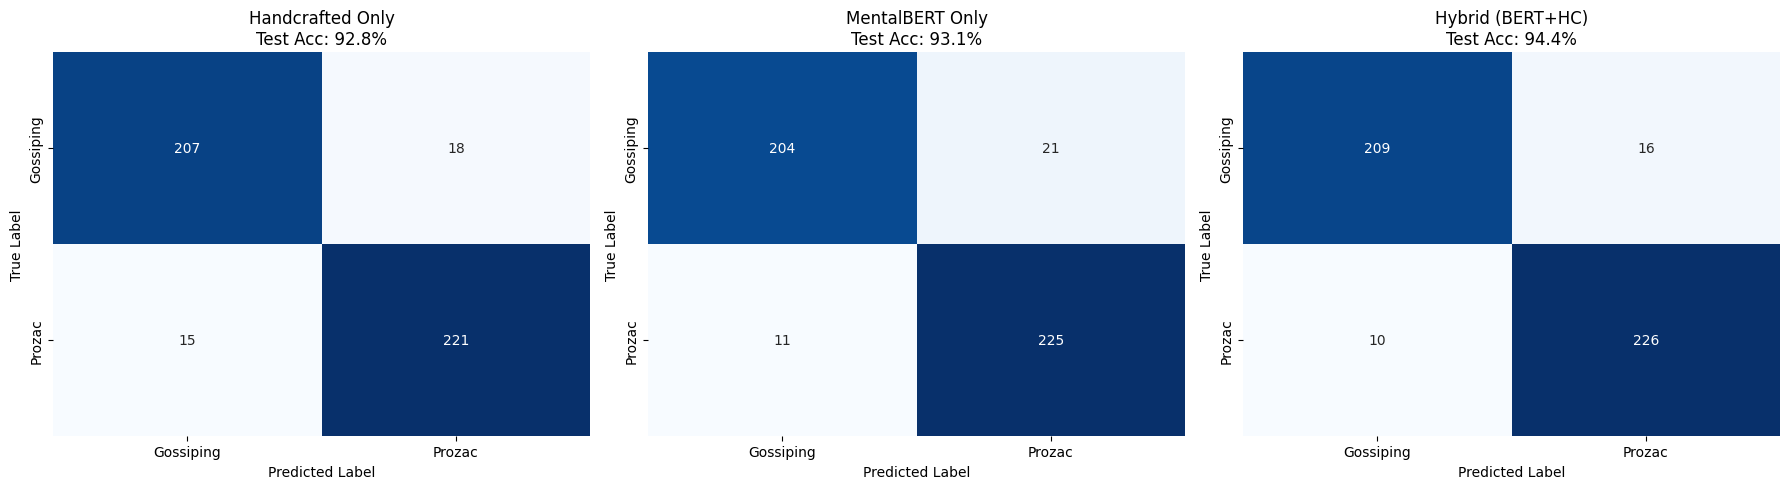


混合模型特徵重要性分析 (Hybrid Model Feature Importance)
   MentalBERT 語意向量 (768 維) 總重要性: 0.8991
   手工語言學特徵 (13 維) 總重要性: 0.1009

[排名] 手工語言學特徵貢獻度排名:
| Feature           |   Importance |
|:------------------|-------------:|
| Adverb_ratio      |       0.0309 |
| I_talk_ratio      |       0.0296 |
| Verb_ratio        |       0.0191 |
| Adj_ratio         |       0.0096 |
| Avg_sent_len      |       0.0057 |
| Cognitive_ratio   |       0.0037 |
| Lexical_diversity |       0.0008 |
| You_talk_ratio    |       0.0006 |
| Negation_ratio    |       0.0003 |
| hour_sin          |       0.0003 |
| He_talk_ratio     |       0.0002 |
| hour_cos          |       0.0001 |
| is_high_risk_time |       0.0000 |


/tmp/ipykernel_1036/3833277772.py:182: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=hc_importance_df, palette=colors)


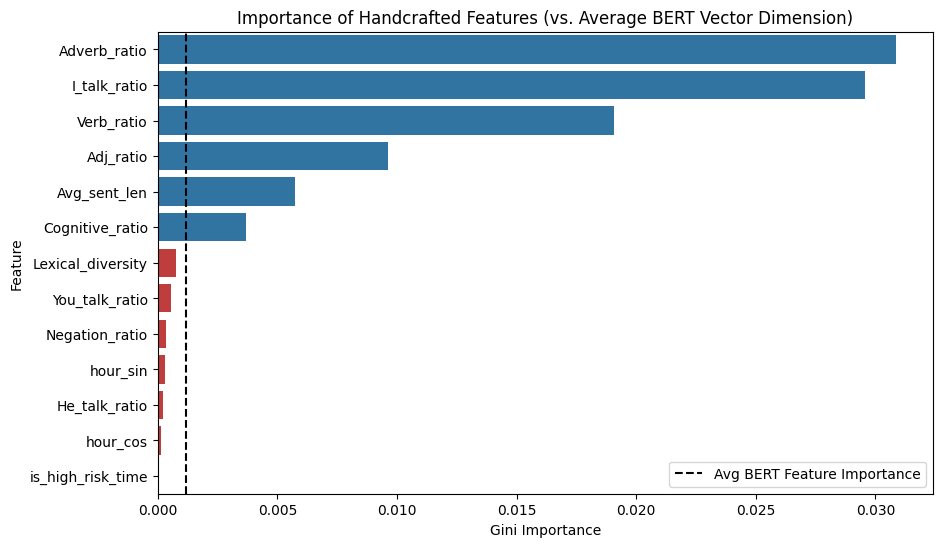


=== 最終實驗結果總結 (Final Experiment Summary) ===
| Model            |   CV Mean Accuracy |   CV Std Dev |   Test Accuracy |
|:-----------------|-------------------:|-------------:|----------------:|
| Handcrafted Only |             0.9192 |       0.0048 |          0.9284 |
| MentalBERT Only  |             0.9400 |       0.0098 |          0.9306 |
| Hybrid (BERT+HC) |             0.9496 |       0.0123 |          0.9436 |


In [ ]:
# =============================================================================
# 特徵消融實驗、模型評估與特徵重要性分析
# 任務：基於隨機森林 (Random Forest) 分類器，比較手工語言學特徵、深度語意特徵及混合模態之預測效能
# =============================================================================



import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# ==========================================
# 0. 參數與路徑設定 (Configurations)
# ==========================================
HC_FILE = "/content/drive/MyDrive/研方期末/features_for_selection.csv"
BERT_FILE = "/content/drive/MyDrive/研方期末/mentalbert_features.csv"

# ==========================================
# 1. 資料載入與特徵整合 (Data Loading and Integration)
# ==========================================
print("[資訊] 開始載入特徵資料集...")

if not os.path.exists(HC_FILE) or not os.path.exists(BERT_FILE):
    print("[錯誤] 找不到特徵檔案，請確認特徵提取模組已順利執行完畢。")
    raise SystemExit

df_hc = pd.read_csv(HC_FILE)
df_bert = pd.read_csv(BERT_FILE)

# 確保兩種模態的資料樣本數完全對齊。若不一致，則取兩者交集 (前 N 筆樣本)
if len(df_hc) != len(df_bert):
    min_len = min(len(df_hc), len(df_bert))
    print(f"[警告] 資料長度不一致。將自動截斷並取前 {min_len} 筆樣本以進行對齊。")
    df_hc = df_hc.iloc[:min_len]
    df_bert = df_bert.iloc[:min_len]

# 設定目標變數 (Labels) 與類別名稱
y = df_hc['label']
target_names = ['Gossiping', 'Prozac']

# --- 特徵空間定義 (Feature Space Definition) ---
# A. 手工語言學與行為特徵 (Handcrafted Features, 共 13 維)
hc_features = [
    # 核心語言學特徵 (反映認知扭曲與反芻思考)
    "Adverb_ratio", "I_talk_ratio", "Verb_ratio", "Adj_ratio",
    "Cognitive_ratio", "Lexical_diversity", "Avg_sent_len", "Negation_ratio",
    # 時間節律特徵 (反映晝夜功能失調)
    "is_high_risk_time", "hour_sin", "hour_cos",
    # 社交互動特徵 (反映社交退縮與孤立)
    "He_talk_ratio", "You_talk_ratio"
]

# 檢查手工特徵欄位是否完整，若有遺失則自動補零以確保程式穩健運行
missing_cols = [c for c in hc_features if c not in df_hc.columns]
if missing_cols:
    print(f"[警告] 手工特徵檔案中遺失以下欄位: {missing_cols}。將以 0 填補。")
    for c in missing_cols:
        df_hc[c] = 0

X_hc = df_hc[hc_features].fillna(0)

# B. MentalBERT 深度語意特徵 (768 維)
bert_cols = [c for c in df_bert.columns if c.startswith('feat_')]
X_bert = df_bert[bert_cols].fillna(0)

# C. 跨模態混合特徵 (Hybrid Features)
X_hybrid = pd.concat([X_bert, X_hc], axis=1)

# 定義消融實驗之對照組字典
experiments = {
    "Handcrafted Only": X_hc,
    "MentalBERT Only": X_bert,
    "Hybrid (BERT+HC)": X_hybrid
}

# ==========================================
# 2. 交叉驗證與模型評估 (Cross-Validation and Evaluation)
# ==========================================
results_summary = []

# 初始化混淆矩陣的視覺化畫布
plt.figure(figsize=(18, 5))
plot_idx = 1

# 定義分層交叉驗證切分器 (Stratified K-Fold)。
# 啟用隨機打散 (shuffle=True) 並固定亂數種子 (random_state=42) 以確保結果具備可重現性。
cv_splitter = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, X_data in experiments.items():
    print(f"\n=== 模型評估階段: {name} ===")

    # --- 步驟 2A: 5-Fold 交叉驗證 (評估模型穩健性) ---
    # 初始化隨機森林分類器，固定 random_state=42
    rf = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)

    cv_scores = cross_val_score(rf, X_data, y, cv=cv_splitter, scoring='accuracy')
    mean_acc = cv_scores.mean()
    std_acc = cv_scores.std()
    print(f"   [交叉驗證] 平均準確率: {mean_acc:.4f} (標準差: {std_acc:.4f})")

    # --- 步驟 2B: 測試集保留評估 (Hold-out Test Evaluation) ---
    # 利用 stratify=y 確保訓練集與測試集的正負樣本比例一致
    X_train, X_test, y_train, y_test = train_test_split(
        X_data, y, test_size=0.2, random_state=42, stratify=y
    )

    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)

    # 彙整評估結果
    results_summary.append({
        "Model": name,
        "CV Mean Accuracy": mean_acc,
        "CV Std Dev": std_acc,
        "Test Accuracy": accuracy_score(y_test, y_pred)
    })

    # 輸出詳細的分類指標報告 (Precision, Recall, F1-Score)
    print("   [測試集] 詳細分類報告:")
    print(classification_report(y_test, y_pred, target_names=target_names, digits=4))

    # --- 步驟 2C: 混淆矩陣視覺化 ---
    cm = confusion_matrix(y_test, y_pred)
    ax = plt.subplot(1, 3, plot_idx)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=target_names, yticklabels=target_names)
    ax.set_title(f"{name}\nTest Acc: {accuracy_score(y_test, y_pred):.1%}")
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")
    plot_idx += 1

plt.tight_layout()
plt.show()

# ==========================================
# 3. 混合模型特徵重要性分析 (Feature Importance Analysis)
# ==========================================
print("\n" + "="*50)
print("混合模型特徵重要性分析 (Hybrid Model Feature Importance)")
print("="*50)

# 使用全量資料重新訓練混合模型，以取得具備全域代表性的特徵重要性權重
rf_hybrid = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
rf_hybrid.fit(X_hybrid, y)

# 提取特徵名稱與對應之吉尼重要性 (Gini Importance)
feature_names = X_hybrid.columns
importances = rf_hybrid.feature_importances_

# 區分深度語意特徵與手工語言學特徵的索引位置
bert_indices = [i for i, col in enumerate(feature_names) if col.startswith('feat_')]
hc_indices = [i for i, col in enumerate(feature_names) if col in hc_features]

# 計算兩大模態之總體重要性
bert_total_imp = np.sum(importances[bert_indices])
hc_total_imp = np.sum(importances[hc_indices])

print(f"   MentalBERT 語意向量 (768 維) 總重要性: {bert_total_imp:.4f}")
print(f"   手工語言學特徵 (13 維) 總重要性: {hc_total_imp:.4f}")

# --- 探討手工特徵之相對貢獻度 ---
# 計算單一 BERT 維度的平均重要性，作為評估手工特徵之基準線 (Benchmark)
avg_bert_imp = np.mean(importances[bert_indices])

hc_importance_df = pd.DataFrame({
    'Feature': [feature_names[i] for i in hc_indices],
    'Importance': importances[hc_indices]
}).sort_values(by='Importance', ascending=False)

print("\n[排名] 手工語言學特徵貢獻度排名:")
print(hc_importance_df.to_markdown(index=False, floatfmt=".4f"))

# 特徵重要性視覺化與基準線對比
plt.figure(figsize=(10, 6))
# 若特徵重要性高於 BERT 單一維度平均值，則以藍色凸顯其顯著性；反之為紅色
colors = ['#1f77b4' if x > avg_bert_imp else '#d62728' for x in hc_importance_df['Importance']]
sns.barplot(x='Importance', y='Feature', data=hc_importance_df, palette=colors)

plt.axvline(x=avg_bert_imp, color='black', linestyle='--', label='Avg BERT Feature Importance')
plt.title("Importance of Handcrafted Features (vs. Average BERT Vector Dimension)")
plt.xlabel("Gini Importance")
plt.legend()
plt.show()

# ==========================================
# 4. 最終實驗結果總結 (Final Summary Table)
# ==========================================
print("\n=== 最終實驗結果總結 (Final Experiment Summary) ===")
summary_df = pd.DataFrame(results_summary)
print(summary_df.to_markdown(index=False, floatfmt=".4f"))

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, f1_score
import numpy as np

# ==========================================
# 0. 設定隨機種子 (確保結果可重現)
# ==========================================
def set_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    torch.backends.cudnn.deterministic = True

set_seed(42)

# ==========================================
# 1. 定義深度融合模型 (MLP Fusion)
# ==========================================
class DepressionFusionNet(nn.Module):
    def __init__(self, bert_dim=768, hc_dim=13):
        super(DepressionFusionNet, self).__init__()

        # 分支 1: 處理 BERT 特徵
        self.bert_layer = nn.Sequential(
            nn.Linear(bert_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.3)
        )

        # 分支 2: 處理手工特徵 (Handcrafted)
        self.hc_layer = nn.Sequential(
            nn.Linear(hc_dim, 64),
            nn.ReLU(),
            nn.BatchNorm1d(64) # 批次標準化，對數值特徵很重要
        )

        # 融合層 (Feature Fusion Layer)
        self.classifier = nn.Sequential(
            nn.Linear(256 + 64, 128), # 拼接兩個分支的輸出
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 1),
            nn.Sigmoid() # 輸出 0~1 的機率值
        )

    def forward(self, bert_x, hc_x):
        b_out = self.bert_layer(bert_x)
        h_out = self.hc_layer(hc_x)

        # 特徵拼接 (Concatenation)
        combined = torch.cat((b_out, h_out), dim=1)

        return self.classifier(combined)

# ==========================================
# 2. 交叉驗證訓練函數 (K-Fold CV)
# ==========================================
def run_deep_learning_cv(X_bert, X_hc, y, n_splits=5, epochs=15, batch_size=32):
    print(f"\n=== Deep Learning: MLP Fusion Model ({n_splits}-Fold CV with Shuffle) ===")

    # 1. 資料前處理：標準化手工特徵

    scaler = StandardScaler()
    X_hc_scaled = scaler.fit_transform(X_hc)

    # 2. 轉換為 PyTorch Tensor
    X_bert_t = torch.tensor(X_bert.values, dtype=torch.float32)
    X_hc_t = torch.tensor(X_hc_scaled, dtype=torch.float32)
    y_t = torch.tensor(y.values, dtype=torch.float32).unsqueeze(1)

    # 3. 設定 K-Fold (加入 Shuffle)
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    # 儲存每折的結果
    fold_accuracies = []
    fold_f1_scores = []

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"   Using device: {device}")

    # 4. 開始交叉驗證迴圈
    for fold, (train_idx, val_idx) in enumerate(skf.split(X_bert_t, y)):
        print(f"\n--- Fold {fold+1}/{n_splits} ---")

        # 根據索引切分資料
        X_b_train, X_b_val = X_bert_t[train_idx], X_bert_t[val_idx]
        X_h_train, X_h_val = X_hc_t[train_idx], X_hc_t[val_idx]
        y_train, y_val = y_t[train_idx], y_t[val_idx]

        # 建立 DataLoader (訓練集要 Shuffle，驗證集不用)
        train_dataset = TensorDataset(X_b_train, X_h_train, y_train)
        val_dataset = TensorDataset(X_b_val, X_h_val, y_val)

        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

        # 每一折都要重新初始化模型，避免資料洩漏
        model = DepressionFusionNet(bert_dim=768, hc_dim=X_hc.shape[1]).to(device)
        optimizer = optim.Adam(model.parameters(), lr=0.001)
        criterion = nn.BCELoss()

        # --- 訓練階段 ---
        model.train()
        for epoch in range(epochs):
            for b_batch, h_batch, y_batch in train_loader:
                b_batch, h_batch, y_batch = b_batch.to(device), h_batch.to(device), y_batch.to(device)

                optimizer.zero_grad()
                outputs = model(b_batch, h_batch)
                loss = criterion(outputs, y_batch)
                loss.backward()
                optimizer.step()

        # --- 驗證階段 ---
        model.eval()
        y_true_list = []
        y_pred_list = []

        with torch.no_grad():
            for b_batch, h_batch, y_batch in val_loader:
                b_batch, h_batch = b_batch.to(device), h_batch.to(device)

                outputs = model(b_batch, h_batch)
                preds = (outputs > 0.5).float().cpu().numpy()

                y_true_list.extend(y_batch.cpu().numpy())
                y_pred_list.extend(preds)

        # 計算該折的分數
        val_acc = accuracy_score(y_true_list, y_pred_list)
        val_f1 = f1_score(y_true_list, y_pred_list)

        fold_accuracies.append(val_acc)
        fold_f1_scores.append(val_f1)

        print(f"   Fold {fold+1} Accuracy: {val_acc:.4f} | F1-Score: {val_f1:.4f}")

    # ==========================================
    # 5. 輸出平均結果
    # ==========================================
    mean_acc = np.mean(fold_accuracies)
    std_acc = np.std(fold_accuracies)
    mean_f1 = np.mean(fold_f1_scores)

    print("\n" + "="*40)
    print(f"FINAL RESULTS ({n_splits}-Fold CV)")
    print("="*40)
    print(f"Average Accuracy: {mean_acc:.4f} (+/- {std_acc:.4f})")
    print(f"Average F1-Score: {mean_f1:.4f}")
    print("-" * 40)

    # 為了看最後一折的詳細報告 (Optional)
    print("\n[Detailed Report for the Last Fold]")
    print(classification_report(y_true_list, y_pred_list, target_names=['Gossiping', 'Prozac'], digits=4))

# ==========================================
# 3. 呼叫執行
# ==========================================
run_deep_learning_cv(X_bert, X_hc, y, n_splits=5)


=== Deep Learning: MLP Fusion Model (5-Fold CV with Shuffle) ===
   Using device: cuda

--- Fold 1/5 ---
   Fold 1 Accuracy: 0.9783 | F1-Score: 0.9787

--- Fold 2/5 ---
   Fold 2 Accuracy: 0.9630 | F1-Score: 0.9639

--- Fold 3/5 ---
   Fold 3 Accuracy: 0.9761 | F1-Score: 0.9764

--- Fold 4/5 ---
   Fold 4 Accuracy: 0.9739 | F1-Score: 0.9746

--- Fold 5/5 ---
   Fold 5 Accuracy: 0.9717 | F1-Score: 0.9719

FINAL RESULTS (5-Fold CV)
Average Accuracy: 0.9726 (+/- 0.0053)
Average F1-Score: 0.9731
----------------------------------------

[Detailed Report for the Last Fold]
              precision    recall  f1-score   support

   Gossiping     0.9569    0.9867    0.9716       225
      Prozac     0.9868    0.9574    0.9719       235

    accuracy                         0.9717       460
   macro avg     0.9719    0.9721    0.9717       460
weighted avg     0.9722    0.9717    0.9717       460

